In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import spikeinterface as si
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm


import sys
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre


import torch.nn.functional as F
from pathlib import Path


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import time
import pickle
import networkx as nx
from probeinterface import write_probeinterface, read_probeinterface, Probe



In [2]:
import ast
import itertools

def create_channel_groups_using_cliques(
    probe,
    cluster_info,
    clique_size=5,
    distance_threshold=None,
    verbose=True,
):
    """根据物理连接关系和 Day1 cluster 的 best_channels 构造固定大小的 clique 通道组。

    步骤：
    1. 计算通道之间的距离矩阵；若未指定阈值，则依据 Day1 中所有长度为 ``clique_size`` 的
       ``best_channels`` 自动推断一个能够覆盖这些通道组合的最大距离阈值。
    2. 在该阈值下构建无向图，寻找所有大小为 ``clique_size`` 的 clique。
       对于 NetworkX 返回的最大团，如果规模大于 ``clique_size``，会枚举其所有长度为
       ``clique_size`` 的子集。
    3. 将找到的 clique 与 `cluster_info` 中的 ``best_channels`` 进行匹配，仅保留存在对应 Day1
       cluster 的通道组合。

    Parameters
    ----------
    probe : Probe
        ProbeInterface 的 ``Probe`` 对象，包含通道位置、contact id 及 device channel id 信息。
    cluster_info : pd.DataFrame
        Day1 的 cluster 信息表，需要包含 ``cluster_id`` 与 ``best_channels`` 两列。
    clique_size : int, default 5
        目标 clique 的通道数量。
    distance_threshold : float, optional
        手动指定的距离阈值（单位：μm）。若为 None，则根据 Day1 ``best_channels`` 自动推断。
    verbose : bool, default True
        是否打印调试信息。

    Returns
    -------
    dict
        键为 ``model_{i}`` 的字典，值包含：
        - ``channel_indices``: Probe contact 索引（0-based）
        - ``device_channel_indices``: device channel id
        - ``contact_ids``: contact id（通常为 1-based）
        - ``n_channels``: clique 大小（恒为 ``clique_size``）
        - ``center``: 通道几何中心 (x, y)
        - ``matched_cluster_ids``: 匹配到的 Day1 cluster id 列表
    """

    channel_positions = np.asarray(probe.contact_positions, dtype=float)
    contact_ids = [int(c) for c in np.asarray(probe.contact_ids).ravel()]
    device_channel_ids = list(probe.device_channel_indices)
    contact_id_to_index = {cid: idx for idx, cid in enumerate(contact_ids)}

    # 解析 Day1 cluster 的 best_channels，筛选长度等于 clique_size 的组合
    best_channel_map = {}
    max_pairwise_distance = 0.0

    for row in cluster_info.itertuples():
        bc_raw = getattr(row, 'best_channels', None)
        if pd.isna(bc_raw):
            continue
        try:
            channels = ast.literal_eval(bc_raw) if isinstance(bc_raw, str) else list(bc_raw)
        except (SyntaxError, ValueError, TypeError):
            continue
        if not isinstance(channels, (list, tuple)) or len(channels) != clique_size:
            continue

        contact_indices = []
        valid = True
        for ch in channels:
            ch_int = int(ch)
            idx = contact_id_to_index.get(ch_int)
            if idx is None:
                valid = False
                break
            contact_indices.append(idx)
        if not valid:
            continue

        contact_indices_sorted = tuple(sorted(contact_indices))
        best_channel_map.setdefault(contact_indices_sorted, []).append(int(getattr(row, 'cluster_id')))

        coords = channel_positions[list(contact_indices_sorted)]
        if coords.shape[0] >= 2:
            pairwise = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)
            max_pairwise_distance = max(max_pairwise_distance, float(np.max(pairwise)))

    if not best_channel_map:
        raise ValueError("cluster_info 中没有解析成功的 best_channels（长度等于 clique_size）。")

    if distance_threshold is None:
        if max_pairwise_distance <= 0:
            distance_threshold = 60.0
        else:
            distance_threshold = max_pairwise_distance + 1e-6
        if verbose:
            print(f"自动推断的距离阈值: {distance_threshold:.2f} μm")

    # 构建基于距离的图
    dist_matrix = np.linalg.norm(channel_positions[:, None, :] - channel_positions[None, :, :], axis=2)
    adjacency = (dist_matrix <= distance_threshold) & (dist_matrix > 0)
    graph = nx.from_numpy_array(adjacency.astype(int))

    # 找到所有规模为 clique_size 的 clique
    candidate_cliques = set()
    for clique in nx.find_cliques(graph):
        if len(clique) < clique_size:
            continue
        if len(clique) == clique_size:
            candidate_cliques.add(tuple(sorted(clique)))
        else:
            for combo in itertools.combinations(clique, clique_size):
                candidate_cliques.add(tuple(sorted(combo)))

    if verbose:
        print(f"找到候选 clique 数量（大小为 {clique_size}）: {len(candidate_cliques)}")

    matched_cliques = []
    for clique in sorted(candidate_cliques):
        cluster_ids = best_channel_map.get(clique)
        if cluster_ids:
            matched_cliques.append((clique, cluster_ids))

    if not matched_cliques:
        raise RuntimeError("未找到与 Day1 best_channels 匹配的 clique，请检查距离阈值或数据。")

    if verbose:
        print(f"匹配到 Day1 best_channels 的 clique 数量: {len(matched_cliques)}")

    groups = {}
    for idx, (clique, cluster_ids) in enumerate(matched_cliques, start=1):
        center = channel_positions[list(clique)].mean(axis=0)
        groups[f'model_{idx}'] = {
            'channel_indices': list(clique),
            'device_channel_indices': [device_channel_ids[i] for i in clique],
            'contact_ids': [contact_ids[i] for i in clique],
            'n_channels': clique_size,
            'center': tuple(center),
            'matched_cluster_ids': cluster_ids,
        }

    if verbose:
        print("\n生成的通道组概览：")
        for gid, info in groups.items():
            print(
                f"{gid}: contact_ids={info['contact_ids']}, "
                f"matched_clusters={info['matched_cluster_ids']}"
            )

    return groups

def plot_channel_groups(probe, channel_groups, output_pdf_path='channel_groups_visualization.pdf'):
    from matplotlib.patches import Rectangle

    channel_positions = probe.contact_positions
    channel_x = channel_positions[:, 0]
    channel_y = channel_positions[:, 1]

    if len(channel_x) > 1:
        x_spacing = np.min(np.diff(np.sort(np.unique(channel_x)))) if len(np.unique(channel_x)) > 1 else 20
        y_spacing = np.min(np.diff(np.sort(np.unique(channel_y)))) if len(np.unique(channel_y)) > 1 else 20
        rect_width = x_spacing * 0.8
        rect_height = y_spacing * 0.6
    else:
        rect_width = 20
        rect_height = 8

    n_groups = len(channel_groups)
    fig_width = max(3 * n_groups, 3)
    fig_height = 12
    fig, axes = plt.subplots(1, n_groups, figsize=(fig_width, fig_height))
    plt.subplots_adjust(left=0.01, right=0.99, top=0.95, bottom=0.05, wspace=0.02)

    if n_groups == 1:
        axes = [axes]

    x_min, x_max = channel_x.min(), channel_x.max()
    y_min, y_max = channel_y.min(), channel_y.max()
    x_range = x_max - x_min
    x_center = (x_max + x_min) / 2
    x_min_expanded = x_center - x_range
    x_max_expanded = x_center + x_range
    y_margin = (y_max - y_min) * 0.1 if (y_max - y_min) > 0 else 50

    for ax, (group_id, group_info) in zip(axes, channel_groups.items()):
        group_channel_indices = set(group_info['channel_indices'])
        for ch_idx, (x, y) in enumerate(zip(channel_x, channel_y)):
            color = '#ED7B85' if ch_idx in group_channel_indices else 'lightgrey'
            alpha = 0.9 if ch_idx in group_channel_indices else 0.4
            rect = Rectangle(
                (x - rect_width / 2, y - rect_height / 2),
                rect_width,
                rect_height,
                facecolor=color,
                alpha=alpha,
                edgecolor='black',
                linewidth=0.5,
            )
            ax.add_patch(rect)

        ax.set_xlim(x_min_expanded, x_max_expanded)
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(
            f"{group_id}\n({group_info['n_channels']} channels)",
            fontsize=10,
            fontweight='bold',
            pad=5,
        )
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])

    with PdfPages(output_pdf_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0.1)

    print(f"\n通道组可视化PDF已保存至: {output_pdf_path}")
    plt.close()


In [3]:
import ast
import itertools

def create_five_channel_cliques(probe, cluster_info, clique_size=5, distance_threshold=None, verbose=True):
    """根据 Day1 的 best_channels 信息生成固定大小的 clique 通道组（完全基于 device channel indices）。"""

    channel_positions = np.asarray(probe.contact_positions, dtype=float)
    device_channel_ids = [int(dc) for dc in np.asarray(probe.device_channel_indices).ravel()]
    device_id_to_index = {dc: idx for idx, dc in enumerate(device_channel_ids)}

    def _channel_to_index(ch_int):
        return device_id_to_index.get(ch_int)

    best_channel_map = {}
    max_pairwise_distance = 0.0

    for row in cluster_info.itertuples():
        bc_raw = getattr(row, 'best_channels', None)
        if pd.isna(bc_raw):
            continue
        try:
            channels = ast.literal_eval(bc_raw) if isinstance(bc_raw, str) else list(bc_raw)
        except (SyntaxError, ValueError, TypeError):
            continue
        if not isinstance(channels, (list, tuple)) or len(channels) != clique_size:
            continue

        contact_indices = []
        device_ids = []
        for ch in channels:
            idx = _channel_to_index(int(ch))
            if idx is None:
                contact_indices = []
                device_ids = []
                break
            contact_indices.append(idx)
            device_ids.append(device_channel_ids[idx])
        if len(contact_indices) != clique_size:
            continue

        device_key = tuple(sorted(device_ids))
        best_channel_map.setdefault(device_key, []).append(int(getattr(row, 'cluster_id')))

        coords = channel_positions[contact_indices]
        if coords.shape[0] >= 2:
            pairwise = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)
            max_pairwise_distance = max(max_pairwise_distance, float(np.max(pairwise)))

    if not best_channel_map:
        raise ValueError("cluster_info 中没有解析成功的 best_channels（长度等于 clique_size）。")

    if distance_threshold is None:
        if max_pairwise_distance <= 0:
            distance_threshold = 60.0
        else:
            distance_threshold = max_pairwise_distance + 1e-6
        if verbose:
            print(f"自动推断的距离阈值: {distance_threshold:.2f} μm")

    dist_matrix = np.linalg.norm(channel_positions[:, None, :] - channel_positions[None, :, :], axis=2)
    adjacency = (dist_matrix <= distance_threshold) & (dist_matrix > 0)
    graph = nx.from_numpy_array(adjacency.astype(int))

    candidate_cliques = set()
    for clique in nx.find_cliques(graph):
        if len(clique) < clique_size:
            continue
        if len(clique) == clique_size:
            candidate_cliques.add(tuple(sorted(clique)))
        else:
            for combo in itertools.combinations(clique, clique_size):
                candidate_cliques.add(tuple(sorted(combo)))

    if verbose:
        print(f"找到候选 clique 数量（大小为 {clique_size}）: {len(candidate_cliques)}")

    matched_cliques = []
    for clique in sorted(candidate_cliques):
        device_key = tuple(sorted(device_channel_ids[i] for i in clique))
        cluster_ids = best_channel_map.get(device_key)
        if cluster_ids:
            matched_cliques.append((clique, device_key, cluster_ids))

    if not matched_cliques:
        raise RuntimeError("未找到与 Day1 best_channels 匹配的 clique，请检查距离阈值或数据。")

    groups = {}
    for idx, (clique_indices, device_key, cluster_ids) in enumerate(matched_cliques, start=1):
        center = channel_positions[list(clique_indices)].mean(axis=0)
        groups[f'model_{idx}'] = {
            'channel_indices': list(clique_indices),
            'device_channel_indices': list(device_key),
            'n_channels': clique_size,
            'center': tuple(center),
            'matched_cluster_ids': cluster_ids,
        }

    if verbose:
        print(f"匹配到 Day1 best_channels 的 clique 数量: {len(groups)}")
        for gid, info in groups.items():
            print(
                f"{gid}: device_channels={info['device_channel_indices']}, matched_clusters={info['matched_cluster_ids']}"
            )

    return groups



In [4]:
def count_array2_in_range_of_array1(array1, array2, threshold=5):

    sorted_array1 = np.sort(array1)
    array2 = np.sort(array2)
    
    lefts = array2 - threshold
    rights = array2 + threshold
    
    left_indices = np.searchsorted(sorted_array1, lefts, side='left')
    
    right_indices = np.searchsorted(sorted_array1, rights, side='right')
    
    has_within_range = right_indices > left_indices
    
    count = np.sum(has_within_range)
    
    return count

def label_array1_based_on_array2(array1, array2, threshold=5):
    array_1 = np.sort(array1)
    sorted_array2 = np.sort(array2)
    
    labels = np.zeros(len(array1), dtype=int)
    
    for i, value in enumerate(array1):
        left = value - threshold
        right = value + threshold
        
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        if right_index > left_index:
            labels[i] = 1
    
    return labels
def detect_local_maxima_in_window(data, window_size=20, std_multiplier=2):
    """检测每个通道的局部极值，返回通道级与全局合并的索引。"""
    per_channel_indices = []
    global_indices_set = set()

    for row in data:
        maxima_indices = []
        row_std = np.std(row.astype(np.float32))
        threshold = std_multiplier * row_std

        for start in range(0, len(row), window_size):
            end = min(start + window_size, len(row))
            window = np.abs(row[start:end])
            if window.size == 0:
                continue
            local_max_index = int(np.argmax(window))
            local_max_value = window[local_max_index]
            if local_max_value > threshold:
                global_idx = start + local_max_index
                maxima_indices.append(global_idx)
                global_indices_set.add(global_idx)

        per_channel_indices.append(np.array(sorted(set(maxima_indices)), dtype=int))

    global_indices = np.array(sorted(global_indices_set), dtype=int)
    return per_channel_indices, global_indices


def cluster_label_array1_based_on_array2(array1, array2, threshold=5):
    """
    根据 array2 的时间与cluster信息，对 array1 中的时间点赋予对应的cluster标签。
    若在指定阈值范围内未找到匹配时间，则标签为0。
    """
    array1 = np.asarray(array1)
    labels = np.zeros(len(array1), dtype=int)
    if array2 is None or len(array2) == 0 or len(array1) == 0:
        return labels
    if hasattr(array2, 'columns'):
        time_column = None
        for col in ['time', 'sample_index']:
            if col in array2.columns:
                time_column = col
                break
        if time_column is None:
            # 回退到按列位置
            time_values = array2.iloc[:, 0].to_numpy()
        else:
            time_values = array2[time_column].to_numpy()
        cluster_column = None
        for col in ['cluster_id', 'cluster']:
            if col in array2.columns:
                cluster_column = col
                break
        if cluster_column is None:
            cluster_values = array2.iloc[:, 1].to_numpy()
        else:
            cluster_values = array2[cluster_column].to_numpy()
    else:
        array2 = np.asarray(array2)
        time_values = array2[:, 0]
        cluster_values = array2[:, 1]
    if len(time_values) == 0:
        return labels
    time_values = np.asarray(time_values)
    cluster_values = np.asarray(cluster_values)
    sorted_indices = np.argsort(time_values)
    sorted_times = time_values[sorted_indices]
    sorted_clusters = cluster_values[sorted_indices]
    for i, value in enumerate(array1):
        left = value - threshold
        right = value + threshold
        left_index = np.searchsorted(sorted_times, left, side='left')
        right_index = np.searchsorted(sorted_times, right, side='right')
        if right_index > left_index:
            try:
                labels[i] = int(sorted_clusters[left_index])
            except (ValueError, TypeError):
                labels[i] = 0
    return labels


def label_array1_based_on_array2(array1, array2, threshold=5):

    """
    根据 array2 的值对 array1 进行标记。
    如果 array1 中的某个值在 threshold 范围内存在于 array2 中，则标记为 1，否则为 0。
    
    参数:
    array1 : numpy.ndarray
        要标记的数组。
    array2 : numpy.ndarray
        用于判断的数组。
    threshold : int
        判断范围的阈值。
    
    返回:
    labels : numpy.ndarray
        长度为 len(array1) 的标签数组，值为 0 或 1。
    """
    # 对 array2 进行排序以加速搜索
    sorted_array2 = np.sort(array2)
    
    # 初始化标签数组，默认值为 0
    labels = np.zeros(len(array1), dtype=int)
    
    # 遍历 array1 中的每个元素
    for i, value in enumerate(array1):
        # 计算当前值的范围
        left = value - threshold
        right = value + threshold
        
        # 使用二分搜索判断范围内是否存在值
        left_index = np.searchsorted(sorted_array2, left, side='left')
        right_index = np.searchsorted(sorted_array2, right, side='right')
        
        # 如果范围内存在值，则标记为 1
        if right_index > left_index:
            labels[i] = 1
    
    return labels


def extract_windows(data, indices, window_size=61):
    """
    根据给定的时间点索引提取窗口。
    
    参数:
    data : numpy.ndarray
        输入数据，形状为 (n_channels, time)
    indices : numpy.ndarray
        时间点索引数组，用于指定需要提取窗口的中心点
    window_size : int
        窗口长度，默认为61（对应time-30到time+31）
    
    返回:
    windows : numpy.ndarray
        提取的窗口数据，形状为 (len(indices), n_channels, window_size)
    """
    n_channels, time_length = data.shape
    half_window = window_size // 2

    if np.any(indices < half_window) or np.any(indices >= time_length - half_window):
        raise ValueError("Some indices are out of bounds for the given window size.")

    windows = []
    for idx in indices:
        window = data[:, idx - half_window:idx + half_window + 1]
        windows.append(window)

    windows = np.array(windows)
    return windows

In [5]:
# UMAP可视化函数
from umap import UMAP
import matplotlib.patches as mpatches

def visualize_model_umap(model_id, model_dir, test_dataset, model, device='cuda', n_samples=100000, 
                         output_pdf_path=None, cluster_labels=None, kmeans_labels=None,
                         kmeans_neuron_labels=None, gt_alignment=None, pred_alignment=None):
    """
    对训练好的模型进行UMAP可视化，并支持额外的聚类/对齐子图。
    """
    model.eval()

    total_len = len(test_dataset)

    def _validate_length(name, arr):
        if arr is None:
            return None
        arr = np.asarray(arr)
        if len(arr) != total_len:
            print(f"警告: {name}长度({len(arr)})与数据集长度({total_len})不一致，忽略{name}绘图")
            return None
        return arr

    cluster_labels = _validate_length('cluster_labels', cluster_labels)
    kmeans_labels = _validate_length('kmeans_labels', kmeans_labels)
    kmeans_neuron_labels = _validate_length('kmeans_neuron_labels', kmeans_neuron_labels)
    gt_alignment = _validate_length('gt_alignment', gt_alignment)
    pred_alignment = _validate_length('pred_alignment', pred_alignment)

    sampled_cluster_labels = None
    sampled_kmeans_labels = None
    sampled_kmeans_neurons = None
    sampled_gt_alignment = None
    sampled_pred_alignment = None

    if total_len > n_samples:
        indices = np.random.choice(total_len, n_samples, replace=False)
        sampled_dataset = torch.utils.data.Subset(test_dataset, indices)
        sampled_loader = DataLoader(sampled_dataset, batch_size=batch_size, shuffle=False)
        if cluster_labels is not None:
            sampled_cluster_labels = cluster_labels[indices]
        if kmeans_labels is not None:
            sampled_kmeans_labels = kmeans_labels[indices]
        if kmeans_neuron_labels is not None:
            sampled_kmeans_neurons = kmeans_neuron_labels[indices]
        if gt_alignment is not None:
            sampled_gt_alignment = gt_alignment[indices]
        if pred_alignment is not None:
            sampled_pred_alignment = pred_alignment[indices]
    else:
        sampled_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        if cluster_labels is not None:
            sampled_cluster_labels = cluster_labels
        if kmeans_labels is not None:
            sampled_kmeans_labels = kmeans_labels
        if kmeans_neuron_labels is not None:
            sampled_kmeans_neurons = kmeans_neuron_labels
        if gt_alignment is not None:
            sampled_gt_alignment = gt_alignment
        if pred_alignment is not None:
            sampled_pred_alignment = pred_alignment

    print(f"\n=== {model_id} UMAP可视化 ===")
    print(f"采样数量: {min(n_samples, total_len)}")

    all_features = []
    all_labels_gt = []
    all_labels_pred = []
    collected_cluster_labels = [] if sampled_cluster_labels is not None else None
    collected_kmeans_labels = [] if sampled_kmeans_labels is not None else None
    collected_kmeans_neurons = [] if sampled_kmeans_neurons is not None else None
    collected_gt_alignment = [] if sampled_gt_alignment is not None else None
    collected_pred_alignment = [] if sampled_pred_alignment is not None else None
    start_idx = 0

    with torch.no_grad():
        for batch_data, batch_labels in sampled_loader:
            batch_size_curr = batch_data.shape[0]
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            features = model.extract_features(batch_data)
            all_features.append(features.cpu().numpy())

            outputs = model(batch_data)
            predicted = (outputs > 0.5).float().squeeze()
            all_labels_pred.append(predicted.cpu().numpy())
            all_labels_gt.append(batch_labels.cpu().numpy())

            if collected_cluster_labels is not None:
                collected_cluster_labels.append(sampled_cluster_labels[start_idx:start_idx + batch_size_curr])
            if collected_kmeans_labels is not None:
                collected_kmeans_labels.append(sampled_kmeans_labels[start_idx:start_idx + batch_size_curr])
            if collected_kmeans_neurons is not None:
                collected_kmeans_neurons.append(sampled_kmeans_neurons[start_idx:start_idx + batch_size_curr])
            if collected_gt_alignment is not None:
                collected_gt_alignment.append(sampled_gt_alignment[start_idx:start_idx + batch_size_curr])
            if collected_pred_alignment is not None:
                collected_pred_alignment.append(sampled_pred_alignment[start_idx:start_idx + batch_size_curr])
            start_idx += batch_size_curr

    all_features = np.concatenate(all_features, axis=0)
    all_labels_gt = np.concatenate(all_labels_gt, axis=0)
    all_labels_pred = np.concatenate(all_labels_pred, axis=0)

    def _stack(collected):
        if isinstance(collected, list) and len(collected) > 0:
            return np.concatenate(collected)
        return None

    collected_cluster_labels = _stack(collected_cluster_labels)
    collected_kmeans_labels = _stack(collected_kmeans_labels)
    collected_kmeans_neurons = _stack(collected_kmeans_neurons)
    collected_gt_alignment = _stack(collected_gt_alignment)
    collected_pred_alignment = _stack(collected_pred_alignment)

    if collected_cluster_labels is not None and len(collected_cluster_labels) != len(all_features):
        print("警告: cluster_labels采样长度与特征数量不匹配，跳过cluster子图")
        collected_cluster_labels = None
    if collected_kmeans_labels is not None and len(collected_kmeans_labels) != len(all_features):
        print("警告: kmeans_labels采样长度与特征数量不匹配，跳过kmeans子图")
        collected_kmeans_labels = None
    if collected_kmeans_neurons is not None and len(collected_kmeans_neurons) != len(all_features):
        print("警告: kmeans_neuron_labels采样长度与特征数量不匹配，跳过Neuron子图")
        collected_kmeans_neurons = None
    if collected_gt_alignment is not None and len(collected_gt_alignment) != len(all_features):
        print("警告: gt_alignment采样长度与特征数量不匹配，跳过Ground Truth对齐子图")
        collected_gt_alignment = None
    if collected_pred_alignment is not None and len(collected_pred_alignment) != len(all_features):
        print("警告: pred_alignment采样长度与特征数量不匹配，跳过预测对齐子图")
        collected_pred_alignment = None

    if collected_kmeans_neurons is not None:
        valid_neuron_mask = np.array([val not in (None, '') for val in collected_kmeans_neurons], dtype=bool)
        if not np.any(valid_neuron_mask):
            collected_kmeans_neurons = None

    print(f"提取的特征形状: {all_features.shape}")
    print(f"Ground truth标签分布: spike={np.sum(all_labels_gt==1)}, noise={np.sum(all_labels_gt==0)}")
    print(f"Predicted标签分布: spike={np.sum(all_labels_pred==1)}, noise={np.sum(all_labels_pred==0)}")

    print("进行UMAP降维...")
    umap_reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(all_features)

    has_cluster_plot = collected_cluster_labels is not None
    has_kmeans_plot = collected_kmeans_labels is not None
    has_kmeans_neuron_plot = collected_kmeans_neurons is not None
    has_gt_alignment_plot = collected_gt_alignment is not None
    has_pred_alignment_plot = collected_pred_alignment is not None

    n_subplots = 2
    if has_cluster_plot:
        n_subplots += 1
    if has_kmeans_neuron_plot:
        n_subplots += 1
    if has_kmeans_plot:
        n_subplots += 1
    if has_gt_alignment_plot:
        n_subplots += 1
    if has_pred_alignment_plot:
        n_subplots += 1

    fig, axes = plt.subplots(1, n_subplots, figsize=(6 * n_subplots, 6))
    axes = np.atleast_1d(axes)
    axes = list(axes)

    subplot_idx = 0

    ax_gt = axes[subplot_idx]
    subplot_idx += 1
    spike_mask_gt = all_labels_gt == 1
    noise_mask_gt = all_labels_gt == 0
    ax_gt.scatter(umap_embedding[noise_mask_gt, 0], umap_embedding[noise_mask_gt, 1],
                  c='lightgrey', alpha=1.0, s=0.1)
    ax_gt.scatter(umap_embedding[spike_mask_gt, 0], umap_embedding[spike_mask_gt, 1],
                  c='#FF8C42', alpha=1.0, s=0.1)
    ax_gt.set_title(f'{model_id} - Ground Truth', fontsize=14, fontweight='bold')

    ax_pred = axes[subplot_idx]
    subplot_idx += 1
    spike_mask_pred = all_labels_pred == 1
    noise_mask_pred = all_labels_pred == 0
    ax_pred.scatter(umap_embedding[noise_mask_pred, 0], umap_embedding[noise_mask_pred, 1],
                    c='lightgrey', alpha=1.0, s=0.1)
    ax_pred.scatter(umap_embedding[spike_mask_pred, 0], umap_embedding[spike_mask_pred, 1],
                    c='#FF8C42', alpha=1.0, s=0.1)
    ax_pred.set_title(f'{model_id} - Predicted Labels', fontsize=14, fontweight='bold')

    if has_cluster_plot:
        ax_cluster = axes[subplot_idx]
        subplot_idx += 1
        cluster_ids = collected_cluster_labels.astype(int)
        noise_mask = cluster_ids == 0
        unique_clusters = [cid for cid in np.unique(cluster_ids) if cid != 0]
        if np.any(noise_mask):
            ax_cluster.scatter(umap_embedding[noise_mask, 0], umap_embedding[noise_mask, 1],
                               c='lightgrey', alpha=1.0, s=0.1, label='Noise/0')
        if unique_clusters:
            cmap = plt.cm.get_cmap('tab20', len(unique_clusters))
            for idx, cid in enumerate(unique_clusters):
                mask = cluster_ids == cid
                ax_cluster.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                                   c=[cmap(idx)], alpha=1.0, s=0.1, label=f'Cluster {cid}')
            if len(unique_clusters) <= 12:
                ax_cluster.legend(fontsize=9, loc='best')
        ax_cluster.set_title(f'{model_id} - Cluster Labels', fontsize=14, fontweight='bold')

    if has_kmeans_neuron_plot:
        ax_kmeans_neuron = axes[subplot_idx]
        subplot_idx += 1
        neuron_ids = np.asarray(collected_kmeans_neurons, dtype=object)
        assigned_mask = np.array([(val is not None) and (val != '') for val in neuron_ids], dtype=bool)
        if np.any(~assigned_mask):
            ax_kmeans_neuron.scatter(umap_embedding[~assigned_mask, 0], umap_embedding[~assigned_mask, 1],
                                     s=0.1, alpha=0.5, color='#B0B0B0', label='未映射')
        unique_neurons = sorted({val for val in neuron_ids if val is not None and val != ''}, key=str)
        if unique_neurons:
            cmap_neuron = plt.cm.get_cmap('tab20', max(len(unique_neurons), 1))
            for idx, neuron in enumerate(unique_neurons):
                mask = neuron_ids == neuron
                ax_kmeans_neuron.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                                         s=0.1, alpha=0.9, color=cmap_neuron(idx % cmap_neuron.N), label=str(neuron))
            if len(unique_neurons) <= 12:
                ax_kmeans_neuron.legend(fontsize=8, loc='best', markerscale=4)
        ax_kmeans_neuron.set_title(f'{model_id} - KMeans Neuron', fontsize=14, fontweight='bold')

    if has_kmeans_plot:
        ax_kmeans = axes[subplot_idx]
        subplot_idx += 1
        kmeans_ids = collected_kmeans_labels.astype(int)
        unique_kmeans = np.unique(kmeans_ids)
        cmap_pred = plt.cm.get_cmap('tab20', max(len(unique_kmeans), 1))
        for idx, cid in enumerate(unique_kmeans):
            mask = kmeans_ids == cid
            if cid < 0:
                color = '#B0B0B0'
                label = 'KMeans: unmapped'
            else:
                color = cmap_pred(idx % cmap_pred.N)
                label = f'KMeans: {cid}'
            ax_kmeans.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
                              s=0.1, alpha=0.9, color=color, label=label)
        if len(unique_kmeans) <= 12:
            ax_kmeans.legend(fontsize=8, loc='best', markerscale=4)
        ax_kmeans.set_title(f'{model_id} - KMeans Cluster', fontsize=14, fontweight='bold')

    if has_gt_alignment_plot:
        ax_gt_align = axes[subplot_idx]
        subplot_idx += 1
        gt_align = collected_gt_alignment.astype(int)
        aligned_mask = gt_align == 1
        unaligned_mask = gt_align != 1
        if np.any(unaligned_mask):
            ax_gt_align.scatter(umap_embedding[unaligned_mask, 0], umap_embedding[unaligned_mask, 1],
                                s=0.1, alpha=0.5, color='#B0B0B0', label='未对齐')
        if np.any(aligned_mask):
            ax_gt_align.scatter(umap_embedding[aligned_mask, 0], umap_embedding[aligned_mask, 1],
                                s=0.1, alpha=0.9, color='#FF8C00', label='已对齐')
        if len(ax_gt_align.collections) <= 2:
            ax_gt_align.legend(fontsize=8, loc='best', markerscale=4)
        ax_gt_align.set_title(f'{model_id} - Ground Truth Alignment', fontsize=14, fontweight='bold')

    if has_pred_alignment_plot:
        ax_pred_align = axes[subplot_idx]
        pred_align = collected_pred_alignment.astype(int)
        aligned_mask = pred_align == 1
        unaligned_mask = pred_align != 1
        if np.any(unaligned_mask):
            ax_pred_align.scatter(umap_embedding[unaligned_mask, 0], umap_embedding[unaligned_mask, 1],
                                   s=0.1, alpha=0.5, color='#B0B0B0', label='未对齐')
        if np.any(aligned_mask):
            ax_pred_align.scatter(umap_embedding[aligned_mask, 0], umap_embedding[aligned_mask, 1],
                                   s=0.1, alpha=0.9, color='#FF8C00', label='已对齐')
        if len(ax_pred_align.collections) <= 2:
            ax_pred_align.legend(fontsize=8, loc='best', markerscale=4)
        ax_pred_align.set_title(f'{model_id} - Predicted Alignment', fontsize=14, fontweight='bold')

    for ax in axes:
        ax.set_aspect('equal', adjustable='box')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

    plt.tight_layout()

    if output_pdf_path is None:
        output_pdf_path = os.path.join(model_dir, f'{model_id}_umap_visualization.pdf')

    with PdfPages(output_pdf_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    print(f"UMAP可视化PDF已保存至: {output_pdf_path}")
    plt.close()

    return umap_embedding, all_labels_gt, all_labels_pred


In [6]:
# 加载probe_4的probe信息
from scipy.io import loadmat

probe_data = loadmat("/media/ubuntu/sda/duan/rat/probe/chanMapQPX_mice1.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y

probe_4 = Probe()
probe_4.set_contacts(positions=probe_position, contact_ids=probe_data['chanMap'][:, 0])
probe_4.set_device_channel_indices(range(128))

# print(f"已加载probe_4的recording数据")
# print(f"通道数: {recording_f.get_num_channels()}")
# print(f"采样率: {recording_f.get_sampling_frequency()} Hz")
# print(f"总帧数: {recording_f.get_num_samples()}")

# 读取 Day1 cluster 信息以获取 best_channels
cluster_inf_probe4 = pd.read_csv(
    "/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv",
    index_col=0,
)

# 使用新的 5 通道 clique 方法创建通道组
channel_groups = create_five_channel_cliques(
    probe=probe_4,
    cluster_info=cluster_inf_probe4,
    clique_size=5,
    distance_threshold=None,
    verbose=True,
)

# 转换为后续处理所需的字典格式
model_channel_dict = {}
for model_id, group_info in channel_groups.items():
    channel_tuple = tuple(sorted(group_info['device_channel_indices']))
    model_channel_dict[channel_tuple] = group_info.get('matched_cluster_ids', [])

print(f"\n创建了{len(model_channel_dict)}个 5 通道模型组")


自动推断的距离阈值: 156.25 μm
找到候选 clique 数量（大小为 5）: 124
匹配到 Day1 best_channels 的 clique 数量: 72
model_1: device_channels=[4, 5, 6, 7, 8], matched_clusters=[7]
model_2: device_channels=[5, 6, 7, 8, 9], matched_clusters=[5]
model_3: device_channels=[6, 7, 8, 9, 10], matched_clusters=[11]
model_4: device_channels=[7, 8, 9, 10, 11], matched_clusters=[13]
model_5: device_channels=[8, 9, 10, 11, 12], matched_clusters=[14]
model_6: device_channels=[9, 10, 11, 12, 13], matched_clusters=[17]
model_7: device_channels=[10, 11, 12, 13, 14], matched_clusters=[18, 20]
model_8: device_channels=[11, 12, 13, 14, 15], matched_clusters=[21]
model_9: device_channels=[12, 13, 14, 15, 16], matched_clusters=[24]
model_10: device_channels=[13, 14, 15, 16, 17], matched_clusters=[23, 26, 30]
model_11: device_channels=[15, 16, 17, 18, 19], matched_clusters=[31]
model_12: device_channels=[17, 18, 19, 20, 21], matched_clusters=[32]
model_13: device_channels=[18, 19, 20, 21, 22], matched_clusters=[35]
model_14: device_chann

In [7]:
recording_raw_path = '/home/ubuntu/Downloads/paper/20250612_1.group0.bin'  # 根据实际路径调整
recording_raw = se.read_binary(recording_raw_path, sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
probe_4_channel_offset = 128 * 3  # probe_4是第4组，索引为3
probe_4_channel_indices = [channel + probe_4_channel_offset for channel in range(128)]
recording_probe4_raw = recording_raw.select_channels(probe_4_channel_indices)
recording_probe4 = spre.bandpass_filter(recording_probe4_raw, freq_min=300, freq_max=3000)
recording_probe4 = spre.notch_filter(recording_probe4, freq=50)
recording_f = spre.common_reference(recording_probe4, reference="global", operator="median")
recording_f = recording_f.set_probegroup(probe_4)


In [8]:
class SpikeDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
    

class Spike_Detection_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size, n_channels, time_window):
        super(Spike_Detection_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 16)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(16, output_size)
        self.sigmoid = nn.Sigmoid()  

        self.n_channels = n_channels
        self.time_window = time_window

    def forward(self, x):
        x = x.reshape(-1, self.n_channels * self.time_window)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x
    
    def extract_features(self, x):
        """
        提取fc3层（relu3之后）的特征
        用于降维可视化
        """
        x = x.reshape(-1, self.n_channels * self.time_window)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)  # fc3的输出，经过relu3激活
        return x


In [9]:
class SpikeClassificationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


class Spike_Classification_MLP(nn.Module):
    """Two-layer classifier on detection embeddings."""

    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc_out = nn.Linear(32, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.reshape(x.size(0), -1)
        else:
            x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc_out(x)


In [10]:
spike_inf_probe4 = pd.read_csv("/media/ubuntu/sda/duan/rat/sorting_results/day1/spike_inf.tsv_probe_4", index_col=0, sep='\t')
cluster_inf_probe4 = pd.read_csv("/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv", index_col=0)

In [ ]:
# 统一处理probe_4的所有5通道模型组
from collections import Counter, OrderedDict
print("=== 开始处理probe_4的多通道模型组 ===")

# 加载 Day1 spike / cluster 信息
spike_inf_probe4 = pd.read_csv(
    "/media/ubuntu/sda/duan/rat/sorting_results/day1/spike_inf.tsv_probe_4",
    index_col=0,
    sep='\t'
)
cluster_inf_probe4 = pd.read_csv(
    "/media/ubuntu/sda/duan/rat/sorting_results/day1/cluster_inf_probe_4.csv",
    index_col=0
)

main_result_dir = '/media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models'
os.makedirs(main_result_dir, exist_ok=True)
classification_main_dir = '/media/ubuntu/sda/duan/rat/spike_classification_results/probe_4_models'
os.makedirs(classification_main_dir, exist_ok=True)

# 训练参数
hidden_size1 = 256
hidden_size2 = 64
output_size = 1
device = 'cuda'
num_epochs = 50
batch_size = 1024
window_size = 71
half_window = window_size // 2
chunk_size = 120000
enable_visualization = True

# 准备通道映射
all_channel_ids = list(recording_f.channel_ids)
channel_id_to_position = {ch_id: idx for idx, ch_id in enumerate(all_channel_ids)}
contact_to_channel_id = {idx: ch_id for idx, ch_id in enumerate(all_channel_ids)}

# 构建每个模型的上下文信息
model_contexts = OrderedDict()
for model_id, group_info in channel_groups.items():
    channel_indices = list(group_info['channel_indices'])
    device_channel_indices = [int(dc) for dc in group_info['device_channel_indices']]
    matched_cluster_ids = [int(cid) for cid in group_info.get('matched_cluster_ids', [])]
    clique_center = tuple(group_info.get('center', (0.0, 0.0)))

    channel_positions = []
    missing_channel = False
    for contact_idx in channel_indices:
        ch_id = contact_to_channel_id.get(contact_idx)
        pos = channel_id_to_position.get(ch_id)
        if ch_id is None or pos is None:
            missing_channel = True
            break
        channel_positions.append(pos)

    if missing_channel or len(channel_positions) != len(channel_indices):
        print(f"警告: {model_id} 的通道索引无法映射到全局录波数据，已跳过。")
        continue

    if matched_cluster_ids:
        spike_subset = spike_inf_probe4[spike_inf_probe4['cluster_id'].isin(matched_cluster_ids)].copy()
    else:
        spike_subset = pd.DataFrame(columns=spike_inf_probe4.columns)

    model_contexts[model_id] = {
        'channel_indices': channel_indices,
        'channel_positions': channel_positions,
        'device_channel_indices': device_channel_indices,
        'matched_cluster_ids': matched_cluster_ids,
        'center': clique_center,
        'spike_info': spike_subset,
        'windows': [],
        'times': []
    }


total_models = len(model_contexts)
print(f"总共需要处理 {total_models} 个模型组")

total_frames = recording_f.get_num_samples()
print(f"检测到recording总帧数: {total_frames}")

# --- 第一步：一次遍历录波，分发所有候选窗口 ---
print("开始遍历录波数据并分发候选窗口...")
for start_frame in tqdm(range(0, total_frames, chunk_size), desc="检测+分发"):
    end_frame = min(start_frame + chunk_size, total_frames)
    try:
        data_chunk = recording_f.get_traces(
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=all_channel_ids
        )
        data_chunk = data_chunk.T  # (n_channels, chunk_length)
    except Exception as exc:
        print(f"读取数据块 [{start_frame}, {end_frame}) 失败: {exc}")
        continue

    try:
        channel_spike_indices, _ = detect_local_maxima_in_window(
            data_chunk,
            std_multiplier=2.5,
            window_size=60
        )
    except Exception as exc:
        print(f"检测局部极值失败: {exc}")
        continue

    for context in model_contexts.values():
        positions = context['channel_positions']
        candidate_set = set()
        for pos in positions:
            spikes = channel_spike_indices[pos]
            if spikes.size > 0:
                candidate_set.update(int(x) for x in spikes)
        if not candidate_set:
            continue

        candidate_indices = np.array(sorted(candidate_set), dtype=int)
        valid_mask = (
            (candidate_indices >= half_window + 1) &
            (candidate_indices < data_chunk.shape[1] - half_window)
        )
        if not np.any(valid_mask):
            continue

        rel_indices = candidate_indices[valid_mask]
        global_indices = rel_indices + start_frame

        try:
            clique_chunk = data_chunk[positions, :]
            windows = extract_windows(clique_chunk, rel_indices, window_size=window_size)
        except Exception:
            continue

        context['windows'].append(windows.astype(np.float32))
        context['times'].append(global_indices.astype(int))

print("候选窗口收集完成。\n")

=== 开始处理probe_4的多通道模型组 ===
总共需要处理 72 个模型组
检测到recording总帧数: 19285560
开始遍历录波数据并分发候选窗口...


检测+分发:  93%|█████████▎| 150/161 [03:32<00:19,  1.82s/it]

In [13]:
# --- 第二步：逐个模型训练 ---
from matplotlib.backends.backend_pdf import PdfPages
from umap import UMAP

all_results = {}
umap_pdf_path = '/media/ubuntu/sda/duan/rat/figure/probe4_day1_training_umap.pdf'
os.makedirs(os.path.dirname(umap_pdf_path), exist_ok=True)
umap_pdf = PdfPages(umap_pdf_path)
umap_pages_generated = 0

for idx, (model_id, context) in enumerate(model_contexts.items(), start=1):
    clique_center = context['center']
    device_channel_indices = context['device_channel_indices']
    matched_cluster_ids = context['matched_cluster_ids']

    print(f"\n{'='*80}")
    print(f"处理第 {idx}/{total_models} 个模型组: {model_id}")
    print(f"{'='*80}")

    model_dir = os.path.join(main_result_dir, model_id)
    os.makedirs(model_dir, exist_ok=True)


    all_valid_indices = np.concatenate(context['times']).astype(int)
    all_windows = np.concatenate(context['windows']).astype(np.float32)

    sort_order = np.argsort(all_valid_indices)
    all_valid_indices = all_valid_indices[sort_order]
    all_windows = all_windows[sort_order]

    spike_inf_temp = context['spike_info']
    if not spike_inf_temp.empty:
        labels = label_array1_based_on_array2(all_valid_indices, spike_inf_temp['time'], threshold=2)
        cluster_labels_full = cluster_label_array1_based_on_array2(all_valid_indices, spike_inf_temp, threshold=2)
    else:
        labels = np.zeros(all_valid_indices.shape[0], dtype=int)
        cluster_labels_full = np.full(all_valid_indices.shape[0], -1, dtype=int)

    cluster_labels_full = np.asarray(cluster_labels_full, dtype=int)
    cluster_labels_full[labels == 0] = -1

    detected_spike_count = int(np.sum(labels == 1))
    total_detected = int(all_valid_indices.size)
    total_real_spikes = int(len(spike_inf_temp))

    detection_recall = detected_spike_count / total_real_spikes * 100 if total_real_spikes > 0 else 0.0
    detection_precision = detected_spike_count / total_detected * 100 if total_detected > 0 else 0.0

    print(f"\n--- Clique信息 ---")
    print(f"真实spike数量: {total_real_spikes:,}")
    print(f"匹配的真实spike数量: {detected_spike_count:,}")
    print(f"检测召回率 (Recall): {detection_recall:.2f}%")
    print(f"检测精确率 (Precision): {detection_precision:.2f}%")

    indices_0 = np.where(labels == 0)[0]
    indices_1 = np.where(labels == 1)[0]
    target_0_count = len(indices_1) * 3

    if len(indices_0) > target_0_count:
        sampled_indices_0 = np.random.choice(indices_0, target_0_count, replace=False)
    else:
        sampled_indices_0 = indices_0

    final_indices = np.concatenate([sampled_indices_0, indices_1])
    np.random.shuffle(final_indices)

    sampled_windows = all_windows[final_indices]
    sampled_labels = labels[final_indices]
    sampled_cluster_labels = cluster_labels_full[final_indices]

    print(f"\n--- 训练数据准备 ---")
    print(f"正样本数量 (spike): {len(indices_1):,}")
    print(f"负样本数量 (non-spike): {len(indices_0):,}")

    dataset = SpikeDataset(sampled_windows, sampled_labels)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    input_size = sampled_windows.shape[1] * sampled_windows.shape[2]
    model = Spike_Detection_MLP(
        input_size,
        hidden_size1,
        hidden_size2,
        output_size,
        n_channels=sampled_windows.shape[1],
        time_window=sampled_windows.shape[2]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.BCELoss()

    print(f"\n--- 开始训练模型 ---")
    training_history = []
    best_tpr = 0.0
    best_model_state = model.state_dict().copy()
    patience = 5
    patience_counter = 0
    best_epoch = -1

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_data, batch_labels in train_loader:
            batch_labels = batch_labels.float().unsqueeze(1).to(device)
            batch_data = batch_data.to(device)

            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)

            predicted = (outputs > 0.5).float()
            train_total += batch_labels.size(0)
            train_correct += (predicted == batch_labels).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        test_correct = 0
        test_total = 0
        true_positive = true_negative = false_positive = false_negative = 0

        with torch.no_grad():
            for batch_data, batch_labels in test_loader:
                batch_labels = batch_labels.float().unsqueeze(1).to(device)
                batch_data = batch_data.to(device)

                outputs = model(batch_data)
                predicted = (outputs > 0.5).float()

                test_total += batch_labels.size(0)
                test_correct += (predicted == batch_labels).sum().item()

                true_positive += ((predicted == 1) & (batch_labels == 1)).sum().item()
                true_negative += ((predicted == 0) & (batch_labels == 0)).sum().item()
                false_positive += ((predicted == 1) & (batch_labels == 0)).sum().item()
                false_negative += ((predicted == 0) & (batch_labels == 1)).sum().item()

        tpr = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
        tnr = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0.0
        accuracy = test_correct / test_total if test_total > 0 else 0.0

        if tpr > best_tpr:
            best_tpr = tpr
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
            if epoch % 5 == 0 or epoch < 5:
                print(f"Epoch {epoch+1:3d}/{num_epochs}: ✓ 新最佳! TPR={tpr:.4f}, TNR={tnr:.4f}, Acc={accuracy:.4f}, Loss={train_loss/len(train_loader):.4f}")
        else:
            patience_counter += 1
            if epoch % 5 == 0 or epoch < 5:
                print(f"Epoch {epoch+1:3d}/{num_epochs}: TPR={tpr:.4f} (最佳: {best_tpr:.4f}), TNR={tnr:.4f}, Acc={accuracy:.4f}, 早停: {patience_counter}/{patience}")

        training_history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss / len(train_loader),
            'train_accuracy': train_correct / train_total if train_total > 0 else 0.0,
            'test_accuracy': accuracy,
            'tpr': tpr,
            'tnr': tnr,
            'best_tpr_so_far': best_tpr,
        })

        if patience_counter >= patience:
            print(f"触发早停条件，在第 {epoch+1} 轮提前终止训练。")
            break

    print(f"\n--- 保存模型和训练结果 ---")
    
    # 保存最佳模型
    model_path = os.path.join(model_dir, f"{model_id}_best_model.pth")
    torch.save({
        'model_state_dict': best_model_state,
        'training_info': {
            'best_epoch': best_epoch + 1,
            'best_tpr': best_tpr,
            'total_epochs_trained': epoch + 1,
            'early_stopped': patience_counter >= patience
        },
    }, model_path)
    print(f"✓ 最佳模型已保存: {model_path}")

    model.load_state_dict(best_model_state)
    model.eval()

    if enable_visualization:
        total_samples = sampled_windows.shape[0]
        if total_samples == 0:
            print("UMAP可视化跳过: 样本为空")
        else:
            sample_size = min(10000, total_samples)
            if total_samples > sample_size:
                rng_vis = np.random.default_rng(20251110 + idx)
                sample_indices = rng_vis.choice(total_samples, size=sample_size, replace=False)
            else:
                sample_indices = np.arange(total_samples)
            sample_indices = np.asarray(sample_indices, dtype=int)

            windows_subset = torch.tensor(sampled_windows[sample_indices], dtype=torch.float32, device=device)
            labels_subset = sampled_labels[sample_indices]
            cluster_subset = sampled_cluster_labels[sample_indices]

            features_collected = []
            preds_collected = []
            with torch.no_grad():
                for start_idx in range(0, windows_subset.shape[0], batch_size):
                    batch_tensor = windows_subset[start_idx:start_idx + batch_size]
                    features = model.extract_features(batch_tensor)
                    outputs = model(batch_tensor)
                    features_collected.append(features.detach().cpu().numpy())
                    preds_collected.append((outputs.detach().cpu().numpy() > 0.5).astype(int).reshape(-1))

            if features_collected:
                features_array = np.concatenate(features_collected, axis=0)
                preds_array = np.concatenate(preds_collected, axis=0).astype(int)
                try:
                    reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
                    embedding = reducer.fit_transform(features_array)
                except Exception as umap_exc:
                    print(f"UMAP降维失败: {umap_exc}")
                    embedding = None

                if embedding is not None and embedding.shape[0] == features_array.shape[0]:
                    x_min, x_max = float(np.min(embedding[:, 0])), float(np.max(embedding[:, 0]))
                    y_min, y_max = float(np.min(embedding[:, 1])), float(np.max(embedding[:, 1]))
                    range_x = x_max - x_min
                    range_y = y_max - y_min
                    max_range = max(range_x, range_y, 1e-6)
                    x_center = (x_max + x_min) / 2.0
                    y_center = (y_max + y_min) / 2.0
                    limit_half = max_range / 2.0 * 1.05

                    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
                    titles = [
                        f"{model_id} - Ground Truth",
                        f"{model_id} - Predicted Label",
                        f"{model_id} - Cluster Label"
                    ]
                    color_spike = '#FF8C42'
                    color_noise = 'lightgrey'

                    noise_mask_gt = labels_subset == 0
                    spike_mask_gt = labels_subset == 1
                    axes[0].scatter(embedding[noise_mask_gt, 0], embedding[noise_mask_gt, 1],
                                    c=color_noise, s=5, alpha=0.45, linewidths=0)
                    axes[0].scatter(embedding[spike_mask_gt, 0], embedding[spike_mask_gt, 1],
                                    c=color_spike, s=5, alpha=0.8, linewidths=0)

                    noise_mask_pred = preds_array == 0
                    spike_mask_pred = preds_array == 1
                    axes[1].scatter(embedding[noise_mask_pred, 0], embedding[noise_mask_pred, 1],
                                    c=color_noise, s=5, alpha=0.45, linewidths=0)
                    axes[1].scatter(embedding[spike_mask_pred, 0], embedding[spike_mask_pred, 1],
                                    c=color_spike, s=5, alpha=0.8, linewidths=0)

                    cluster_subset_int = cluster_subset.astype(int)
                    noise_mask_cluster = cluster_subset_int < 0
                    axes[2].scatter(embedding[noise_mask_cluster, 0], embedding[noise_mask_cluster, 1],
                                    c=color_noise, s=5, alpha=0.4, linewidths=0)
                    unique_clusters = [cid for cid in np.unique(cluster_subset_int) if cid >= 0]
                    if unique_clusters:
                        cmap = plt.cm.get_cmap('tab20', len(unique_clusters))
                        for idx_c, cid in enumerate(unique_clusters):
                            mask = cluster_subset_int == cid
                            axes[2].scatter(embedding[mask, 0], embedding[mask, 1],
                                            c=[cmap(idx_c)], s=5, alpha=0.8, linewidths=0,
                                            label=str(cid))
                        if len(unique_clusters) <= 12:
                            axes[2].legend(loc='best', fontsize=6, markerscale=2)

                    for ax, title in zip(axes, titles):
                        ax.set_xlim(x_center - limit_half, x_center + limit_half)
                        ax.set_ylim(y_center - limit_half, y_center + limit_half)
                        ax.set_aspect('equal', 'box')
                        ax.set_xticks([])
                        ax.set_yticks([])
                        ax.set_title(title, fontsize=10)

                    plt.tight_layout()
                    umap_pdf.savefig(fig, bbox_inches='tight')
                    plt.close(fig)
                    umap_pages_generated += 1
                else:
                    print("UMAP降维结果无效，跳过可视化。")
            else:
                print("未收集到用于UMAP的特征，跳过可视化。")

            del windows_subset

umap_pdf.close()
if umap_pages_generated > 0:
    print(f"FC3特征UMAP可视化PDF已保存至: {umap_pdf_path}")
else:
    print("未生成FC3特征UMAP可视化页面。")




处理第 1/72 个模型组: model_1

--- Clique信息 ---
真实spike数量: 28,060
匹配的真实spike数量: 28,245
检测召回率 (Recall): 100.66%
检测精确率 (Precision): 7.40%

--- 训练数据准备 ---
正样本数量 (spike): 28,245
负样本数量 (non-spike): 353,426

--- 开始训练模型 ---
Epoch   1/50: ✓ 新最佳! TPR=0.8803, TNR=0.9484, Acc=0.9315, Loss=0.4210
Epoch   2/50: ✓ 新最佳! TPR=0.9161, TNR=0.9531, Acc=0.9439, Loss=0.1643
Epoch   3/50: ✓ 新最佳! TPR=0.9254, TNR=0.9534, Acc=0.9465, Loss=0.1351
Epoch   4/50: ✓ 新最佳! TPR=0.9360, TNR=0.9516, Acc=0.9477, Loss=0.1259
Epoch   5/50: TPR=0.9336 (最佳: 0.9360), TNR=0.9535, Acc=0.9486, 早停: 1/5
Epoch   6/50: ✓ 新最佳! TPR=0.9408, TNR=0.9519, Acc=0.9492, Loss=0.1158
Epoch  11/50: TPR=0.9247 (最佳: 0.9408), TNR=0.9614, Acc=0.9523, 早停: 5/5
触发早停条件，在第 11 轮提前终止训练。

--- 保存模型和训练结果 ---
✓ 最佳模型已保存: /media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models/model_1/model_1_best_model.pth

处理第 2/72 个模型组: model_2

--- Clique信息 ---
真实spike数量: 57,309
匹配的真实spike数量: 49,391
检测召回率 (Recall): 86.18%
检测精确率 (Precision): 12.30%

--- 训练数据准备 ---
正样本数量 (

KeyboardInterrupt: 

## Day1 Waveform Recalibration


In [ ]:
import numpy as np
import pickle

templates_output_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl'

if 'model_contexts' not in globals() or not model_contexts:
    print("model_contexts为空，请先完成候选窗口收集。")
else:
    recalculated_templates = {}
    recalculated_summary = []

    for model_id, context in model_contexts.items():
        times_list = context.get('times')
        windows_list = context.get('windows')
        if not times_list or not windows_list:
            continue

        try:
            all_times = np.concatenate(times_list).astype(int)
            all_windows = np.concatenate(windows_list).astype(np.float32)
        except ValueError:
            continue

        if all_times.size == 0 or all_windows.size == 0:
            continue

        sort_idx = np.argsort(all_times)
        all_times = all_times[sort_idx]
        all_windows = all_windows[sort_idx]

        spike_info = context.get('spike_info')
        if spike_info is None or spike_info.empty:
            continue

        time_col = 'time' if 'time' in spike_info.columns else spike_info.columns[0]
        labels = np.asarray(label_array1_based_on_array2(all_times, spike_info[time_col], threshold=2), dtype=int)
        cluster_labels = np.asarray(cluster_label_array1_based_on_array2(all_times, spike_info, threshold=2), dtype=int)
        if cluster_labels.shape[0] != all_times.shape[0]:
            continue
        cluster_labels[labels == 0] = -1

        unique_clusters = sorted(cid for cid in np.unique(cluster_labels) if cid >= 0)
        if not unique_clusters:
            continue

        channel_indices = list(context.get('channel_indices', []))
        if not channel_indices:
            continue
        channel_positions = np.asarray(probe_4.contact_positions[channel_indices], dtype=float)

        model_templates = {}
        clusters_updated = 0

        for cluster_id in unique_clusters:
            mask = cluster_labels == cluster_id
            cluster_windows = all_windows[mask]
            if cluster_windows.size == 0:
                continue

            rms_per_channel = np.sqrt(np.mean(cluster_windows ** 2, axis=(0, 2)))
            total_amp = rms_per_channel.sum()
            if total_amp > 0:
                weights = rms_per_channel / total_amp
            else:
                weights = np.ones(cluster_windows.shape[1], dtype=float) / cluster_windows.shape[1]

            mean_waveform_channels = np.mean(cluster_windows, axis=0)
            synth_waveform = np.sum(mean_waveform_channels * weights[:, None], axis=0)
            synth_waveform = synth_waveform - np.mean(synth_waveform)
            std_waveform = np.std(synth_waveform)
            if std_waveform > 0:
                synth_waveform = synth_waveform / std_waveform

            cluster_pos = np.sum(channel_positions * weights[:, None], axis=0)

            channel_ids = []
            for idx in channel_indices:
                ch_id = recording_f.channel_ids[idx]
                try:
                    channel_ids.append(int(ch_id))
                except (TypeError, ValueError):
                    channel_ids.append(ch_id)

            model_templates[int(cluster_id)] = {
                'waveform': synth_waveform.astype(np.float32).tolist(),
                'channel_waveforms': mean_waveform_channels.astype(np.float32).tolist(),
                'position': cluster_pos.astype(np.float32).tolist(),
                'n_spikes': int(cluster_windows.shape[0]),
                'channel_indices': channel_indices,
                'channel_ids': channel_ids,
                'position_top_channels': len(channel_indices),
                'merged_from': [int(cluster_id)],
            }
            clusters_updated += 1

        if clusters_updated > 0:
            recalculated_templates[model_id] = model_templates
            recalculated_summary.append((model_id, clusters_updated))

    if recalculated_summary:
        with open(templates_output_path, 'wb') as f:
            pickle.dump(recalculated_templates, f)
        print(f"已重新计算 {len(recalculated_summary)} 个模型的Day1模板，并覆盖保存至: {templates_output_path}")
    else:
        print("未能根据当前model_contexts计算新的模板，请检查输入数据。")


已重新计算 72 个模型的Day1模板，并覆盖保存至: /media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl
 - model_1: 更新 1 个cluster模板
 - model_2: 更新 1 个cluster模板
 - model_3: 更新 1 个cluster模板
 - model_4: 更新 1 个cluster模板
 - model_5: 更新 1 个cluster模板
 - model_6: 更新 1 个cluster模板
 - model_7: 更新 2 个cluster模板
 - model_8: 更新 1 个cluster模板
 - model_9: 更新 1 个cluster模板
 - model_10: 更新 3 个cluster模板
 - model_11: 更新 1 个cluster模板
 - model_12: 更新 1 个cluster模板
 - model_13: 更新 1 个cluster模板
 - model_14: 更新 1 个cluster模板
 - model_15: 更新 1 个cluster模板
 - model_16: 更新 1 个cluster模板
 - model_17: 更新 1 个cluster模板
 - model_18: 更新 1 个cluster模板
 - model_19: 更新 1 个cluster模板
 - model_20: 更新 2 个cluster模板
 - model_21: 更新 1 个cluster模板
 - model_22: 更新 1 个cluster模板
 - model_23: 更新 1 个cluster模板
 - model_24: 更新 2 个cluster模板
 - model_25: 更新 1 个cluster模板
 - model_26: 更新 1 个cluster模板
 - model_27: 更新 1 个cluster模板
 - model_28: 更新 1 个cluster模板
 - model_29: 更新 1 个cluster模板
 - model_30: 更新 1 个cluster模板
 - model_31: 更新 1 个cluster模板
 - model_

# Evluation

In [11]:
day2_recording_raw_path = '/home/ubuntu/Downloads/paper/20250613_1.group0.bin'

recording_raw_day2 = se.read_binary(day2_recording_raw_path, sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
probe_4_channel_offset = 128 * 3  # probe_4是第4组，索引为3
probe_4_channel_indices = [channel + probe_4_channel_offset for channel in range(128)]
recording_day2_raw = recording_raw_day2.select_channels(probe_4_channel_indices)

print("预处理day2 recording...")
recording_day2 = spre.bandpass_filter(recording_day2_raw, freq_min=300, freq_max=3000)
recording_day2 = spre.notch_filter(recording_day2, freq=50)
recording_day2_f = spre.common_reference(recording_day2, reference="global", operator="median")
recording_day2_f = recording_day2_f.set_probegroup(probe_4)

print(f"day2 recording信息:")

spike_inf_day2_path = '/media/ubuntu/sda/duan/rat/sorting_results/aligned/probe_4_day2_spikes_with_alignment.tsv'
cluster_inf_day2_path = '/media/ubuntu/sda/duan/rat/sorting_results/aligned/probe_4_day2_clusters_with_alignment.csv'


spike_inf_day2 = pd.read_csv(spike_inf_day2_path, sep='\t')
cluster_inf_day2 = pd.read_csv(cluster_inf_day2_path)


预处理day2 recording...
day2 recording信息:


In [19]:
from collections import OrderedDict

eval_model_context = OrderedDict()
print("=== 构建 Day2 评估模型上下文并分发候选窗口 ===")

window_size_eval = 71
half_window_eval = window_size_eval // 2
chunk_size_eval = 120000

all_channel_ids_day2 = list(recording_day2_f.channel_ids)
channel_id_to_idx_day2 = {ch_id: idx for idx, ch_id in enumerate(all_channel_ids_day2)}

for model_id, group_info in channel_groups.items():
    channel_indices = list(group_info.get('channel_indices', []))
    if not channel_indices:
        print(f"警告: {model_id} 缺少 channel_indices，跳过。")
        continue

    channel_ids = []
    channel_positions_geom = []
    channel_indices_recording = []
    skip_model = False

    for idx in channel_indices:
        if idx >= len(recording_day2_f.channel_ids):
            print(f"警告: {model_id} 通道索引 {idx} 超出 day2 录波通道范围，跳过该模型。")
            skip_model = True
            break
        ch_id = recording_day2_f.channel_ids[idx]
        rec_idx = channel_id_to_idx_day2.get(ch_id)
        if rec_idx is None:
            print(f"警告: {model_id} 的通道 {ch_id} 在 Day2 录波中未找到，跳过。")
            skip_model = True
            break
        channel_ids.append(ch_id)
        channel_indices_recording.append(rec_idx)
        if idx < len(probe_4.contact_positions):
            channel_positions_geom.append(probe_4.contact_positions[idx])
        else:
            channel_positions_geom.append((np.nan, np.nan))

    if skip_model or not channel_indices_recording:
        print(f"跳过 {model_id}: 通道映射失败。")
        continue

    eval_model_context[model_id] = {
        'channel_indices': channel_indices,
        'channel_ids': channel_ids,
        'channel_positions': channel_positions_geom,
        'channel_indices_recording': channel_indices_recording,
        'matched_cluster_ids': [int(cid) for cid in group_info.get('matched_cluster_ids', [])],
        'center': group_info.get('center'),
        'times': [],
        'windows': [],
    }

print(f"共构建 {len(eval_model_context)} 个模型的评估上下文。")

day2_total_frames = recording_day2_f.get_num_samples()
print(f"Day2 录波总帧数: {day2_total_frames}")

if not eval_model_context:
    print("没有可用模型，跳过候选分发。")
else:
    print("开始Day2候选窗口分发...")
    for start_frame in tqdm(range(0, day2_total_frames, chunk_size_eval), desc="Day2 分发"):
        end_frame = min(start_frame + chunk_size_eval, day2_total_frames)
        try:
            data_chunk = recording_day2_f.get_traces(
                start_frame=start_frame,
                end_frame=end_frame,
                channel_ids=all_channel_ids_day2
            )
            data_chunk = data_chunk.T  # (n_channels, chunk_length)
        except Exception as exc:
            print(f"读取数据块 [{start_frame}, {end_frame}) 失败: {exc}")
            continue

        try:
            channel_spike_indices, _ = detect_local_maxima_in_window(
                data_chunk,
                std_multiplier=2.5,
                window_size=60
            )
        except Exception as exc:
            print(f"局部极值检测失败: {exc}")
            continue

        for context in eval_model_context.values():
            positions = context['channel_indices_recording']
            candidate_set = set()
            for pos in positions:
                spikes = channel_spike_indices[pos]
                if spikes.size > 0:
                    candidate_set.update(int(x) for x in spikes)
            if not candidate_set:
                continue

            candidate_indices = np.array(sorted(candidate_set), dtype=int)
            valid_mask = (
                (candidate_indices >= half_window_eval + 1) &
                (candidate_indices < data_chunk.shape[1] - half_window_eval)
            )
            if not np.any(valid_mask):
                continue

            rel_indices = candidate_indices[valid_mask]
            global_indices = rel_indices + start_frame

            try:
                clique_chunk = data_chunk[positions, :]
                windows = extract_windows(clique_chunk, rel_indices, window_size=window_size_eval)
            except Exception as exc:
                print(f"提取窗口失败: {exc}")
                continue

            context['times'].append(global_indices.astype(int))
            context['windows'].append(windows.astype(np.float32))

    total_events = sum(
        sum(len(arr) for arr in context['times'])
        for context in eval_model_context.values()
    )
    print(f"Day2 候选窗口分发完成，总事件数: {total_events}")

=== 构建 Day2 评估模型上下文并分发候选窗口 ===
共构建 72 个模型的评估上下文。
Day2 录波总帧数: 18105146
开始Day2候选窗口分发...


Day2 分发: 100%|██████████| 151/151 [04:20<00:00,  1.73s/it]

Day2 候选窗口分发完成，总事件数: 26579207


In [21]:
hidden_size1 = 256
hidden_size2 = 64
output_size = 1
device = 'cuda'
batch_size = 1024
window_size = 71
half_window = window_size // 2
chunk_size = 120000
main_result_dir = '/media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models'

In [22]:
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
from scipy.spatial import ConvexHull
from matplotlib.path import Path

def _prepare_waveform(array_like):
    if array_like is None:
        return None
    arr = np.asarray(array_like, dtype=float)
    if arr.size == 0:
        return None
    arr = arr - np.mean(arr)
    std = np.std(arr)
    if std > 0:
        arr = arr / std
    return arr

calibration_duration_sec = 60
window_size_eval = 71
half_window_eval = window_size_eval // 2
chunk_size_eval = 120000
batch_size_eval = 1024
kmeans_random_state = 42
waveform_corr_threshold = 0.9
position_delta_threshold = 10.0

templates_output_path = '/media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl'
if 'recalculated_templates' in globals() and recalculated_templates:
    day1_templates = recalculated_templates
else:
    if os.path.exists(templates_output_path):
        with open(templates_output_path, 'rb') as f:
            day1_templates = pickle.load(f)
        print(f"已从 {templates_output_path} 载入 Day1 模板，共 {len(day1_templates)} 个模型")
    else:
        day1_templates = {}
        print(f"警告: 未找到模板文件 {templates_output_path}，评估将无法匹配Day1模板。")

potential_spike_tables = []
alignment_summaries = []
skipped_models = []

sampling_rate_day2 = recording_day2_f.get_sampling_frequency()
calibration_frame_limit = int(calibration_duration_sec * sampling_rate_day2)

print("\n==============================")
print(f"开始Day2评估，共 {len(eval_model_context)} 个模型")
print("==============================\n")

for idx_model, (model_id, context) in enumerate(eval_model_context.items(), start=1):
    print(f"\n{'='*80}")
    print(f"评估第 {idx_model}/{len(eval_model_context)} 个模型: {model_id}")
    print(f"{'='*80}")

    channel_ids = context.get('channel_ids', [])
    channel_positions = np.asarray(context.get('channel_positions', []), dtype=float)
    if len(channel_ids) == 0:
        print("跳过: 缺少可用通道。")
        skipped_models.append((model_id, 'no_channels'))
        continue

    model_templates = day1_templates.get(model_id, {}) if day1_templates else {}
    if not model_templates:
        print("警告: Day1 模板缺失，无法进行对齐，跳过该模型。")
        skipped_models.append((model_id, 'no_day1_template'))
        continue

    if not context['times']:
        print("无候选窗口，跳过该模型。")
        skipped_models.append((model_id, 'no_candidates'))
        continue

    all_times = np.concatenate(context['times']).astype(int)
    all_windows = np.concatenate(context['windows']).astype(np.float32)

    sort_order = np.argsort(all_times)
    all_times = all_times[sort_order]
    all_windows = all_windows[sort_order]

    # Ground truth 标签
    if spike_inf_day2.empty:
        spike_inf_temp = pd.DataFrame(columns=spike_inf_day2.columns)
    else:
        cluster_ids_in_clique = []
        if {'position_1', 'position_2'}.issubset(cluster_inf_day2.columns):
            try:
                clique_positions = probe_4.contact_positions[context['channel_indices']]
                if clique_positions.shape[0] >= 3:
                    hull = ConvexHull(clique_positions)
                    hull_points = clique_positions[hull.vertices]
                    hull_path = Path(hull_points)
                    cluster_positions = cluster_inf_day2[['position_1', 'position_2']].to_numpy()
                    mask_clique = hull_path.contains_points(cluster_positions)
                else:
                    x_min, x_max = clique_positions[:, 0].min(), clique_positions[:, 0].max()
                    y_min, y_max = clique_positions[:, 1].min(), clique_positions[:, 1].max()
                    cluster_positions = cluster_inf_day2[['position_1', 'position_2']].to_numpy()
                    mask_clique = (
                        (cluster_positions[:, 0] >= x_min) & (cluster_positions[:, 0] <= x_max) &
                        (cluster_positions[:, 1] >= y_min) & (cluster_positions[:, 1] <= y_max)
                    )
                cluster_ids_in_clique = cluster_inf_day2.loc[mask_clique, 'cluster_id'].astype(int).tolist()
            except Exception:
                cluster_ids_in_clique = cluster_inf_day2.get('cluster_id', pd.Series(dtype=int)).astype(int).tolist()
        else:
            cluster_ids_in_clique = cluster_inf_day2.get('cluster_id', pd.Series(dtype=int)).astype(int).tolist()

        if cluster_ids_in_clique:
            cluster_col = 'cluster_id' if 'cluster_id' in spike_inf_day2.columns else 'cluster'
            spike_inf_temp = spike_inf_day2[spike_inf_day2[cluster_col].isin(cluster_ids_in_clique)].copy()
        else:
            spike_inf_temp = spike_inf_day2.copy()

    if spike_inf_temp.empty:
        print("警告: Day2 spike 信息缺失，标签全部视为噪声。")

    labels = label_array1_based_on_array2(all_times, spike_inf_temp['time'], threshold=2) if not spike_inf_temp.empty else np.zeros(all_times.shape[0], dtype=int)
    cluster_labels_full = cluster_label_array1_based_on_array2(all_times, spike_inf_temp, threshold=2) if not spike_inf_temp.empty else np.full(all_times.shape[0], -1, dtype=int)
    cluster_labels_full = np.asarray(cluster_labels_full, dtype=int)
    cluster_labels_full[np.asarray(labels) == 0] = -1

    dataset = SpikeDataset(all_windows, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size_eval, shuffle=False)

    model = Spike_Detection_MLP(
        all_windows.shape[1] * all_windows.shape[2],
        hidden_size1,
        hidden_size2,
        output_size,
        n_channels=all_windows.shape[1],
        time_window=all_windows.shape[2]
    ).to(device)

    model_path = os.path.join(main_result_dir, model_id, f"{model_id}_best_model.pth")
    if not os.path.exists(model_path):
        print(f"错误: 未找到模型权重 {model_path}")
        skipped_models.append((model_id, 'missing_model'))
        continue

    state_dict = torch.load(model_path, map_location=device)
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
    else:
        model.load_state_dict(state_dict)
    model.eval()

    all_predictions = []
    all_labels_gt = []
    all_features = []

    with torch.no_grad():
        for batch_data, batch_labels in dataloader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data)
            features = model.extract_features(batch_data)
            all_predictions.append((outputs.cpu().numpy() > 0.5).astype(int).reshape(-1))
            all_labels_gt.append(batch_labels.cpu().numpy().astype(int).reshape(-1))
            all_features.append(features.cpu().numpy().astype(np.float32))

    all_predictions = np.concatenate(all_predictions).astype(int)
    all_labels_gt = np.concatenate(all_labels_gt).astype(int)
    all_features = np.concatenate(all_features, axis=0).astype(np.float32)

    detection_positive_mask = all_predictions == 1
    calibration_mask = (all_times < calibration_frame_limit) & detection_positive_mask

    if not np.any(calibration_mask):
        print("未在前60秒内检测到预测spike，跳过该模型。")
        skipped_models.append((model_id, 'no_calibration_spikes'))
        continue

    calibration_features = all_features[calibration_mask]
    calibration_windows = all_windows[calibration_mask]

    n_day1_clusters = max(len(model_templates), 1)
    n_kmeans_clusters = min(len(calibration_features), n_day1_clusters)
    if n_kmeans_clusters <= 0:
        print("校准样本过少，跳过该模型。")
        skipped_models.append((model_id, 'insufficient_calibration'))
        continue

    print(f"KMeans 聚类 (n_clusters={n_kmeans_clusters})...")
    kmeans = KMeans(n_clusters=n_kmeans_clusters, random_state=kmeans_random_state, n_init=10)
    kmeans_labels_cal = kmeans.fit_predict(calibration_features)

    kmeans_cluster_info = {}
    for lbl in np.unique(kmeans_labels_cal):
        mask_lbl = kmeans_labels_cal == lbl
        windows_lbl = calibration_windows[mask_lbl]
        if windows_lbl.size == 0:
            continue
        rms_per_channel = np.sqrt(np.mean(windows_lbl ** 2, axis=(0, 2)))
        total_amp = rms_per_channel.sum()
        if total_amp > 0:
            weights = rms_per_channel / total_amp
        else:
            weights = np.ones(windows_lbl.shape[1], dtype=float) / windows_lbl.shape[1]
        mean_waveforms = np.mean(windows_lbl, axis=0)
        synth_waveform = np.sum(mean_waveforms * weights[:, None], axis=0)
        synth_waveform = synth_waveform - np.mean(synth_waveform)
        std_waveform = np.std(synth_waveform)
        if std_waveform > 0:
            synth_waveform = synth_waveform / std_waveform
        cluster_pos = np.sum(channel_positions * weights[:, None], axis=0) if channel_positions.size > 0 else np.array([np.nan, np.nan])
        kmeans_cluster_info[int(lbl)] = {
            'waveform': synth_waveform.astype(np.float32),
            'position': cluster_pos.astype(np.float32),
            'n_samples': int(windows_lbl.shape[0])
        }

    alignment_map = {}
    alignment_records = []
    for lbl, info in kmeans_cluster_info.items():
        template_waveform = info['waveform']
        template_pos = info['position']
        best_match = None
        best_corr = -1.0
        best_delta = np.inf

        for day1_cluster_id, tmpl in model_templates.items():
            ref_waveform = _prepare_waveform(tmpl.get('waveform'))
            if ref_waveform is None or ref_waveform.size != template_waveform.size:
                continue
            ref_pos = np.asarray(tmpl.get('position'), dtype=float)
            corr, _ = pearsonr(template_waveform, ref_waveform)
            delta_pos = float(np.linalg.norm(template_pos - ref_pos)) if ref_pos.size == 2 else np.inf
            if corr >= waveform_corr_threshold and delta_pos <= position_delta_threshold:
                if corr > best_corr:
                    best_corr = corr
                    best_delta = delta_pos
                    best_match = int(day1_cluster_id)

        if best_match is not None:
            alignment_map[int(lbl)] = best_match
            alignment_records.append({
                'kmeans_cluster': int(lbl),
                'aligned_day1_cluster': best_match,
                'waveform_corr': best_corr,
                'position_delta': best_delta,
                'samples': info['n_samples']
            })

    if not alignment_map:
        print("未找到满足阈值的对齐Day1 cluster，跳过后续预测。")
        skipped_models.append((model_id, 'no_alignment'))
        continue

    print(f"找到 {len(alignment_map)} 个对齐的 KMeans cluster。")
    alignment_summaries.append({'model_id': model_id, 'aligned_clusters': len(alignment_map)})

    kmeans_labels_all = kmeans.predict(all_features)
    mapped_clusters = np.full(all_predictions.shape, -1, dtype=int)
    predicted_alignment = np.full(all_predictions.shape, -1, dtype=int)

    for lbl, day1_cluster in alignment_map.items():
        mask = (kmeans_labels_all == lbl) & detection_positive_mask
        mapped_clusters[mask] = day1_cluster
        predicted_alignment[mask] = 1

    ground_truth_alignment = np.where((all_labels_gt == 1) & (cluster_labels_full >= 0), 1, -1).astype(int)

    result_df = pd.DataFrame({
        'time': all_times.astype(int),
        'ground_truth_spike_detection': all_labels_gt,
        'predicted_spike_detection': all_predictions,
        'ground_truth_spike_classification': cluster_labels_full.astype(int),
        'predicted_spike_classification': mapped_clusters.astype(int),
        'ground_truth_alignment': ground_truth_alignment,
        'predicted_alignment': predicted_alignment,
        'kmeans_cluster': kmeans_labels_all.astype(int)
    })

    result_path = os.path.join(main_result_dir, model_id, 'day2_potential_spikes.csv')
    os.makedirs(os.path.join(main_result_dir, model_id), exist_ok=True)
    result_df.to_csv(result_path, index=False)
    potential_spike_tables.append((model_id, result_df))
    print(f"结果已保存: {result_path}")

print("\n==============================")
print("Day2 评估完成")
print(f"成功对齐模型: {len(alignment_summaries)} / {len(eval_model_context)}")
if skipped_models:
    print("以下模型未完成评估:")
    for model_id, reason in skipped_models:
        print(f" - {model_id}: {reason}")
print("==============================\n")


已从 /media/ubuntu/sda/duan/rat/sorting_results/day1/day1_model_templates.pkl 载入 Day1 模板，共 72 个模型

开始Day2评估，共 72 个模型


评估第 1/72 个模型: model_1
KMeans 聚类 (n_clusters=1)...
找到 1 个对齐的 KMeans cluster。
结果已保存: /media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models/model_1/day2_potential_spikes.csv

评估第 2/72 个模型: model_2
KMeans 聚类 (n_clusters=1)...
找到 1 个对齐的 KMeans cluster。
结果已保存: /media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models/model_2/day2_potential_spikes.csv

评估第 3/72 个模型: model_3
KMeans 聚类 (n_clusters=1)...
找到 1 个对齐的 KMeans cluster。
结果已保存: /media/ubuntu/sda/duan/rat/spike_detection_results/probe_4_models/model_3/day2_potential_spikes.csv

评估第 4/72 个模型: model_4


KeyboardInterrupt: 

,model_id,total_events,gt_spike,pred_spike,tp_detection,fp_detection,fn_detection,precision_detection,recall_detection,gt_aligned,pred_aligned,tp_alignment,precision_alignment,recall_alignment,unique_pred_clusters,mapped_cluster_ids
49,model_55,164422,40500,28748,28321,427,12179,0.985147,0.699284,40500,28748,28321,0.985147,0.699284,1,[157]
34,model_39,167943,1796,1345,1320,25,476,0.981413,0.734967,1796,1345,1320,0.981413,0.734967,1,[111]
41,model_47,228560,16115,5108,4750,358,11365,0.929914,0.294756,16115,5108,4750,0.929914,0.294756,1,[130]
17,model_21,277042,84811,20083,18661,1422,66150,0.929194,0.220030,84811,20083,18661,0.929194,0.220030,1,[54]
18,model_22,263387,63674,29885,26211,3674,37463,0.877062,0.411644,63674,29885,26211,0.877062,0.411644,1,[53]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,model_33,231561,17484,34770,107,34663,17377,0.003077,0.006120,17484,34770,107,0.003077,0.006120,1,[81]
57,model_63,184144,19441,14366,44,14322,19397,0.003063,0.002263,19441,14366,44,0.003063,0.002263,1,[181]
39,model_44,226219,13742,12744,25,12719,13717,0.001962,0.001819,13742,12744,25,0.001962,0.001819,1,[128]
10,model_14,241011,10895,11607,18,11589,10877,0.001551,0.001652,10895,11607,18,0.001551,0.001652,1,[36]



===== 全局指标 =====
models_evaluated: 67
total_events: 14534734
total_gt_spike: 2489430
total_pred_spike: 1446119
weighted_precision_detection: 0.45330985900883675
weighted_recall_detection: 0.26332935651936384
weighted_precision_alignment: 0.45207067579483873
weighted_recall_alignment: 0.25453738405980486

===== 未完成评估的模型统计 =====
no_alignment: 5


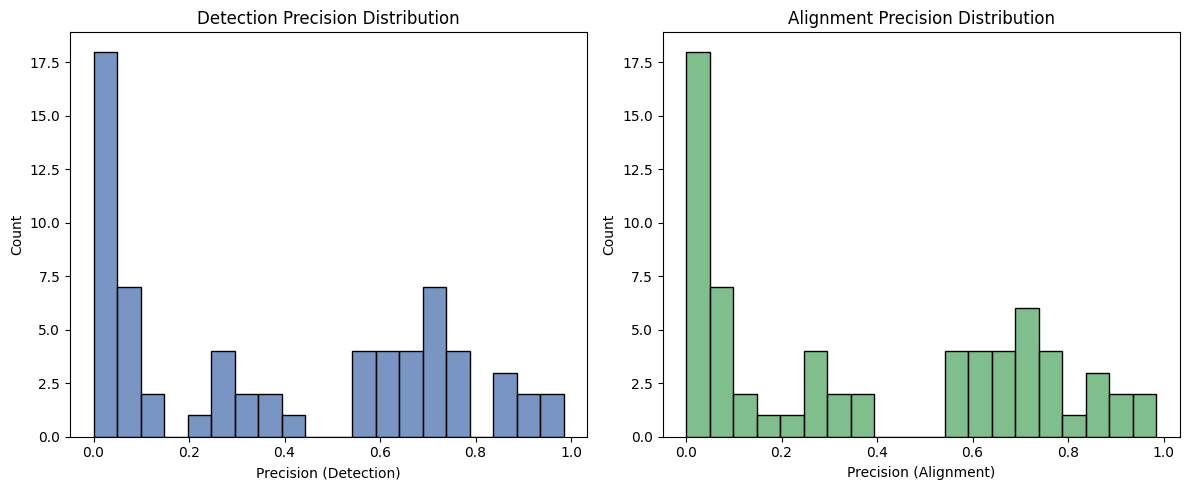

In [ ]:
from collections import defaultdict

summary_records = []
model_level_details = {}

for model_id in ['model_1', 'model_2', 'model_3']:
    result_path = os.path.join(main_result_dir, model_id, 'day2_potential_spikes.csv')
    if not os.path.exists(result_path):
        continue
    result_df = pd.read_csv(result_path)
    if result_df.empty:
        continue

    total_events = len(result_df)
    gt_spike = int((result_df['ground_truth_spike_detection'] == 1).sum())
    pred_spike = int((result_df['predicted_spike_detection'] == 1).sum())

    tp_detection = int(((result_df['ground_truth_spike_detection'] == 1) & (result_df['predicted_spike_detection'] == 1)).sum())
    fp_detection = pred_spike - tp_detection
    fn_detection = gt_spike - tp_detection

    precision_det = tp_detection / pred_spike if pred_spike > 0 else np.nan
    recall_det = tp_detection / gt_spike if gt_spike > 0 else np.nan

    gt_aligned = int((result_df['ground_truth_alignment'] == 1).sum())
    pred_aligned = int((result_df['predicted_alignment'] == 1).sum())
    tp_alignment = int(((result_df['ground_truth_alignment'] == 1) & (result_df['predicted_alignment'] == 1)).sum())

    precision_align = tp_alignment / pred_aligned if pred_aligned > 0 else np.nan
    recall_align = tp_alignment / gt_aligned if gt_aligned > 0 else np.nan

    mapped_clusters = result_df.loc[result_df['predicted_spike_classification'] >= 0, 'predicted_spike_classification']
    unique_mapped_clusters = sorted(mapped_clusters.unique().tolist()) if not mapped_clusters.empty else []

    summary_records.append({
        'model_id': model_id,
        'total_events': total_events,
        'gt_spike': gt_spike,
        'pred_spike': pred_spike,
        'tp_detection': tp_detection,
        'fp_detection': fp_detection,
        'fn_detection': fn_detection,
        'precision_detection': precision_det,
        'recall_detection': recall_det,
        'gt_aligned': gt_aligned,
        'pred_aligned': pred_aligned,
        'tp_alignment': tp_alignment,
        'precision_alignment': precision_align,
        'recall_alignment': recall_align,
        'unique_pred_clusters': len(unique_mapped_clusters),
        'mapped_cluster_ids': unique_mapped_clusters
    })

    model_level_details[model_id] = {
        'result_df': result_df,
        'unique_clusters': unique_mapped_clusters
    }

summary_df = pd.DataFrame(summary_records)

if summary_df.empty:
    print("未找到任何模型的评估结果，请先运行Day2评估单元。")
else:
    summary_df = summary_df.sort_values('precision_detection', ascending=False)
    display(summary_df)

    weighted_precision_det = summary_df['tp_detection'].sum() / summary_df['pred_spike'].sum() if summary_df['pred_spike'].sum() > 0 else np.nan
    weighted_recall_det = summary_df['tp_detection'].sum() / summary_df['gt_spike'].sum() if summary_df['gt_spike'].sum() > 0 else np.nan
    weighted_precision_align = summary_df['tp_alignment'].sum() / summary_df['pred_aligned'].sum() if summary_df['pred_aligned'].sum() > 0 else np.nan
    weighted_recall_align = summary_df['tp_alignment'].sum() / summary_df['gt_aligned'].sum() if summary_df['gt_aligned'].sum() > 0 else np.nan

    overall_metrics = {
        'models_evaluated': len(summary_df),
        'total_events': int(summary_df['total_events'].sum()),
        'total_gt_spike': int(summary_df['gt_spike'].sum()),
        'total_pred_spike': int(summary_df['pred_spike'].sum()),
        'weighted_precision_detection': weighted_precision_det,
        'weighted_recall_detection': weighted_recall_det,
        'weighted_precision_alignment': weighted_precision_align,
        'weighted_recall_alignment': weighted_recall_align,
    }

    print("\n===== 全局指标 =====")
    for k, v in overall_metrics.items():
        print(f"{k}: {v}")

    if 'skipped_models' in globals() and skipped_models:
        skip_counter = defaultdict(int)
        for model_id, reason in skipped_models:
            skip_counter[reason] += 1
        print("\n===== 未完成评估的模型统计 =====")
        for reason, count in skip_counter.items():
            print(f"{reason}: {count}")

    # 可视化 (可选)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(data=summary_df, x='precision_detection', bins=20, ax=axes[0], color='#4C72B0')
    axes[0].set_title('Detection Precision Distribution')
    axes[0].set_xlabel('Precision (Detection)')

    sns.histplot(data=summary_df, x='precision_alignment', bins=20, ax=axes[1], color='#55A868')
    axes[1].set_title('Alignment Precision Distribution')
    axes[1].set_xlabel('Precision (Alignment)')
    plt.tight_layout()
    plt.show()

